In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv(
    '../data/Global YouTube Statistics.csv',
    encoding='latin1'
)

df.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,video_views_rank,country_rank,channel_type_rank,video_views_for_the_last_30_days,lowest_monthly_earnings,highest_monthly_earnings,lowest_yearly_earnings,highest_yearly_earnings,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,1.0,1.0,1.0,2.258000e+09,564600.0,9000000.00,6800000.00,1.084000e+08,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,4055159.0,7670.0,7423.0,1.200000e+01,0.0,0.05,0.04,5.800000e-01,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,48.0,1.0,1.0,1.348000e+09,337000.0,5400000.00,4000000.00,6.470000e+07,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,2.0,2.0,1.0,1.975000e+09,493800.0,7900000.00,5900000.00,9.480000e+07,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,3.0,2.0,2.0,1.824000e+09,455900.0,7300000.00,5500000.00,8.750000e+07,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [3]:
df.shape

(995, 28)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   rank                                     995 non-null    int64  
 1   Youtuber                                 995 non-null    str    
 2   subscribers                              995 non-null    int64  
 3   video views                              995 non-null    float64
 4   category                                 949 non-null    str    
 5   Title                                    995 non-null    str    
 6   uploads                                  995 non-null    int64  
 7   Country                                  873 non-null    str    
 8   Abbreviation                             873 non-null    str    
 9   channel_type                             965 non-null    str    
 10  video_views_rank                         994 non-null    floa

In [5]:
df.isnull().sum().sort_values(ascending=False)

subscribers_for_last_30_days               337
Latitude                                   123
Urban_population                           123
Longitude                                  123
Population                                 123
Gross tertiary education enrollment (%)    123
Unemployment rate                          123
Abbreviation                               122
Country                                    122
country_rank                               116
video_views_for_the_last_30_days            56
category                                    46
channel_type_rank                           33
channel_type                                30
created_month                                5
created_year                                 5
created_date                                 5
video_views_rank                             1
rank                                         0
Youtuber                                     0
Title                                        0
uploads      

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.columns.tolist()

['rank',
 'Youtuber',
 'subscribers',
 'video views',
 'category',
 'Title',
 'uploads',
 'Country',
 'Abbreviation',
 'channel_type',
 'video_views_rank',
 'country_rank',
 'channel_type_rank',
 'video_views_for_the_last_30_days',
 'lowest_monthly_earnings',
 'highest_monthly_earnings',
 'lowest_yearly_earnings',
 'highest_yearly_earnings',
 'subscribers_for_last_30_days',
 'created_year',
 'created_month',
 'created_date',
 'Gross tertiary education enrollment (%)',
 'Population',
 'Unemployment rate',
 'Urban_population',
 'Latitude',
 'Longitude']

In [8]:
df_clean = df.copy()

# Fill missing categories
df_clean['category'] = df_clean['category'].fillna('Unknown')

# Fill missing countries
df_clean['Country'] = df_clean['Country'].fillna('Unknown')

df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   rank                                     995 non-null    int64  
 1   Youtuber                                 995 non-null    str    
 2   subscribers                              995 non-null    int64  
 3   video views                              995 non-null    float64
 4   category                                 995 non-null    str    
 5   Title                                    995 non-null    str    
 6   uploads                                  995 non-null    int64  
 7   Country                                  995 non-null    str    
 8   Abbreviation                             873 non-null    str    
 9   channel_type                             965 non-null    str    
 10  video_views_rank                         994 non-null    floa

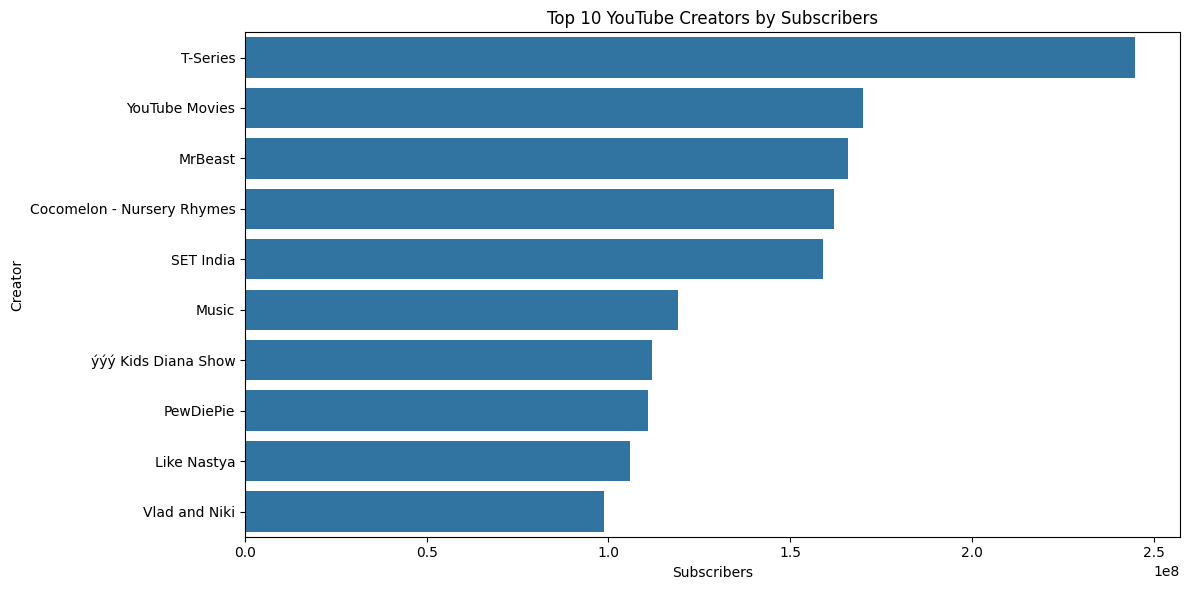

"\nInsight:\nThe subscriber distribution is highly concentrated among a few top creators.\nT-Series leads the ranking, followed by other globally recognized channels.\nThis indicates that a small number of creators capture a significant share of YouTube's audience.\n"

In [18]:
#Top 10 Creators by Subscribers
top_creators = (
    df_clean[['Youtuber', 'subscribers']]
    .sort_values(by='subscribers', ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_creators,
    x='subscribers',
    y='Youtuber'
)

plt.title('Top 10 YouTube Creators by Subscribers')
plt.xlabel('Subscribers')
plt.ylabel('Creator')

plt.tight_layout()

plt.savefig(
    '../images/top_10_creators_by_subscribers.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

'''
Insight:
The subscriber distribution is highly concentrated among a few top creators.
T-Series leads the ranking, followed by other globally recognized channels.
This indicates that a small number of creators capture a significant share of YouTube's audience.
'''

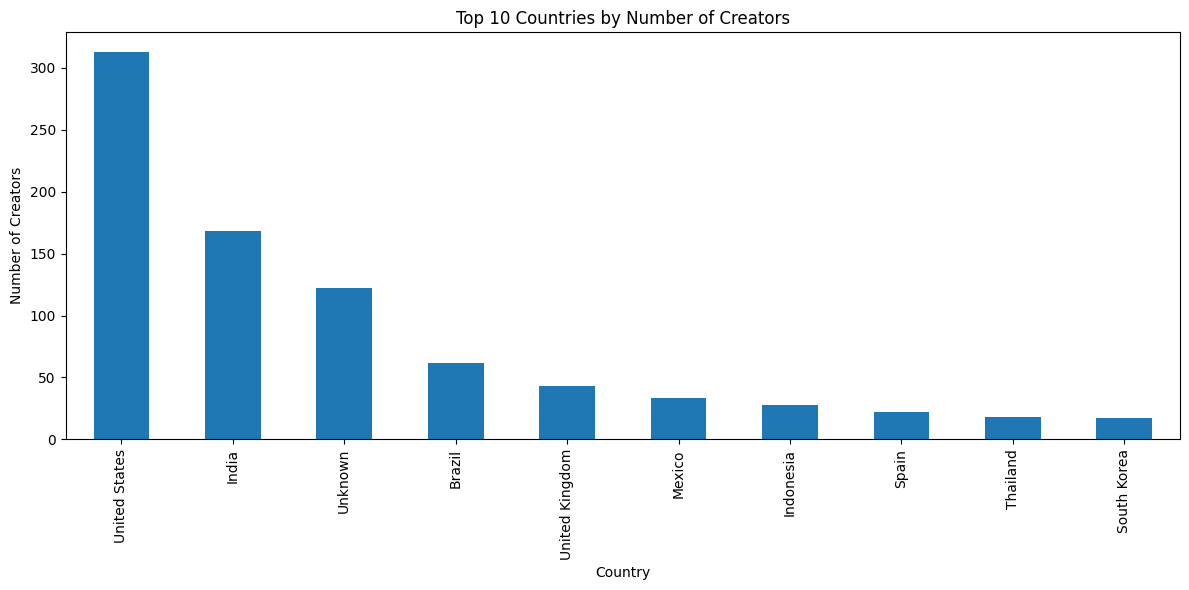

In [17]:
# Country-wise Creator Distribution
top_countries = (
    df_clean['Country']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

top_countries.plot(kind='bar')

plt.title('Top 10 Countries by Number of Creators')
plt.xlabel('Country')
plt.ylabel('Number of Creators')

plt.tight_layout()

plt.savefig(
    '../images/country_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

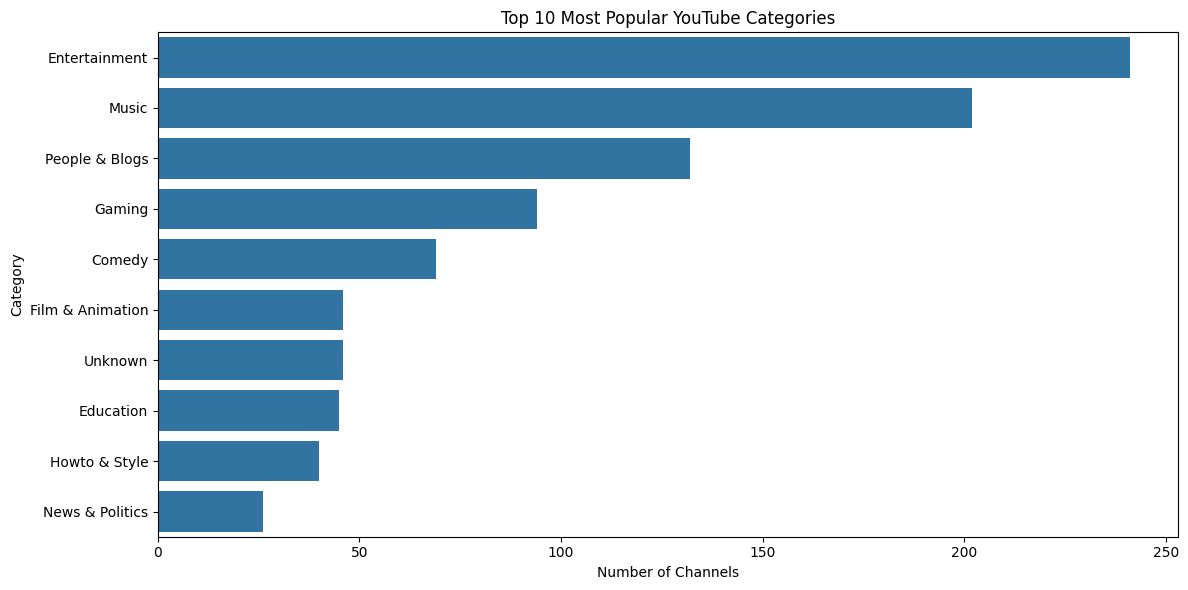

In [19]:
#Category Popularity
#Which content categories dominate YouTube?

top_categories = (
    df_clean['category']
    .value_counts()
    .head(10)
)

top_categories

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title('Top 10 Most Popular YouTube Categories')
plt.xlabel('Number of Channels')
plt.ylabel('Category')

plt.tight_layout()

plt.savefig(
    '../images/category_popularity.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

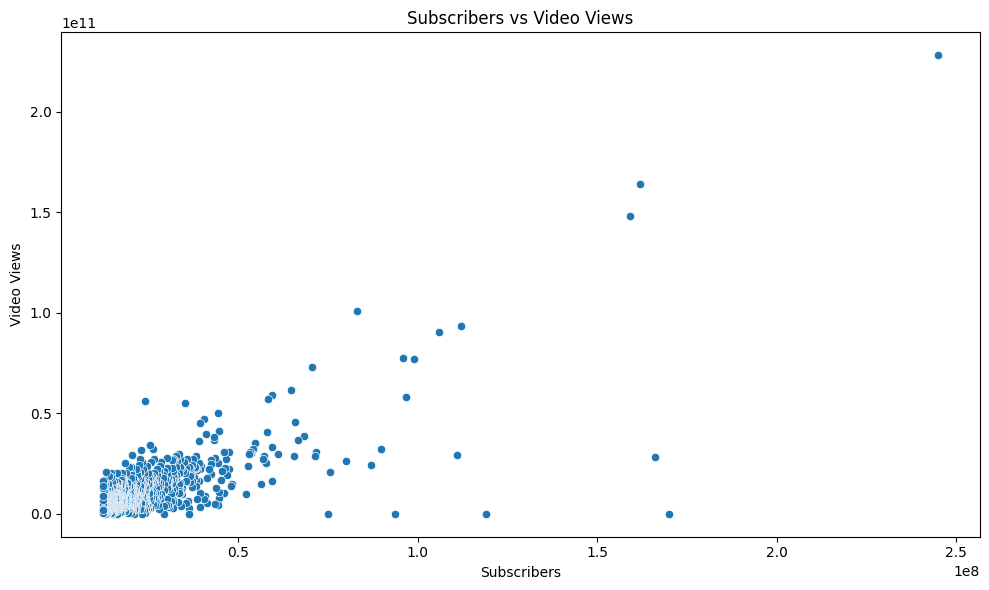

In [20]:
#Views vs Subscribers
#Do more subscribers mean more views?

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_clean,
    x='subscribers',
    y='video views'
)

plt.title('Subscribers vs Video Views')
plt.xlabel('Subscribers')
plt.ylabel('Video Views')

plt.tight_layout()

plt.savefig(
    '../images/views_vs_subscribers.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

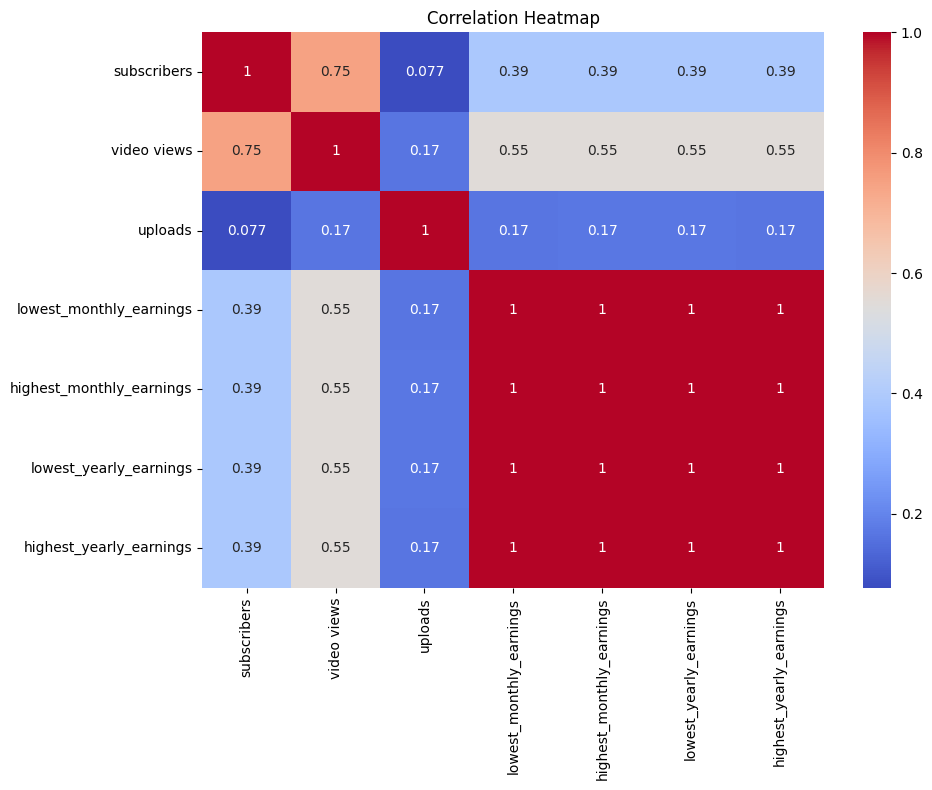

In [21]:
#Correlation Heatmap
#Which numerical features are most related?

numeric_cols = [
    'subscribers',
    'video views',
    'uploads',
    'lowest_monthly_earnings',
    'highest_monthly_earnings',
    'lowest_yearly_earnings',
    'highest_yearly_earnings'
]

corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.tight_layout()

plt.savefig(
    '../images/correlation_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
## Key Findings
'''
1. T-Series is the most subscribed channel in the dataset.

2. The United States contributes the highest number of top YouTube creators.

3. Entertainment and Music are the most common content categories.

4. Subscriber count and video views exhibit a strong positive relationship.

5. Earnings are strongly correlated with views and subscriber counts.

6. A small number of creators dominate YouTube's audience and engagement metrics.
'''